# Deep SARSA Snake – Model Analysis

This notebook evaluates the trained **Deep SARSA** agent used in the Snake environment.

### Objectives:
- Load and inspect the trained Deep SARSA model  
- Validate the model architecture  
- Prepare the environment and agent setup for evaluation  

> This notebook assumes that you have already trained the model using the training notebook.


In [1]:
# ============================================================
# Deep SARSA Snake - Model Analysis Notebook
# ============================================================
# Evaluate a trained Deep SARSA (with or without replay/target)
# ============================================================

import torch
import numpy as np
import matplotlib.pyplot as plt
import importlib, dsarsa_snake
importlib.reload(dsarsa_snake)
from collections import Counter
import os

# Import from your implementation file
from dsarsa_snake import (
    SnakeGame,
    DeepSarsaAgent,
    D_SARSA,
    GRID_SIZE,
    MODEL_PATH,
    USE_REPLAY_BUFFER,
    USE_TARGET
)

# ------------------------------------------------------------
# 1️⃣ Initialize environment and agent (consistent with training)
# ------------------------------------------------------------
env = SnakeGame(grid_size=GRID_SIZE)
agent = DeepSarsaAgent(
    use_target=USE_TARGET,
    replay_buffer=USE_REPLAY_BUFFER
)

# ------------------------------------------------------------
# 2️⃣ Load trained model
# ------------------------------------------------------------
if os.path.exists(MODEL_PATH):
    agent.model.load_state_dict(torch.load(MODEL_PATH, map_location='cpu'))
    agent.model.eval()
    print(f"✓ Loaded trained model from: {MODEL_PATH}")
else:
    raise FileNotFoundError("Trained model not found. Please run the training notebook first.")

# Display architecture
agent.model


✓ Loaded trained model from: improved_D_SARSA_snake_10x10.pth


D_SARSA(
  (fc1): Linear(in_features=16, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=512, bias=True)
  (fc3): Linear(in_features=512, out_features=256, bias=True)
  (fc4): Linear(in_features=256, out_features=3, bias=True)
  (dropout): Dropout(p=0.05, inplace=False)
)

## Run Evaluation Episodes

In this step, we evaluate the **trained Deep SARSA agent** over multiple episodes to measure:
- **Score per episode** – number of food items collected  
- **Total reward** – cumulative return for each episode  
- **Action distribution** – frequency of actions taken  
- **Q-values** – network confidence per action  

*During evaluation, the agent runs in pure exploitation mode (`epsilon = 0.0`), meaning it acts deterministically based on learned policy.*


In [2]:
# ------------------------------------------------------------
# 3️⃣ Evaluation parameters
# ------------------------------------------------------------
num_episodes = 1000
scores, rewards, actions_all, q_values_all = [], [], [], []

print(f"Running {num_episodes} evaluation episodes...")
agent.epsilon = 0.0   # Pure exploitation during evaluation

for ep in range(num_episodes):
    state = env.reset()
    done = False
    total_reward = 0
    actions = []
    q_vals = []

    while not done:
        state_tensor = torch.FloatTensor(state).unsqueeze(0)
        with torch.no_grad():
            q_values = agent.model(state_tensor).squeeze().numpy()

        action = np.argmax(q_values)
        actions.append(action)
        q_vals.append(q_values)

        next_state, reward, done = env.step(action)
        total_reward += reward
        state = next_state

    scores.append(env.score)
    rewards.append(total_reward)
    actions_all.extend(actions)
    q_values_all.extend(q_vals)

print("✓ Evaluation complete.")


Running 1000 evaluation episodes...
✓ Evaluation complete.


## Plot Performance Metrics

We now visualize how the trained **Deep SARSA agent** performed across all evaluation episodes.

### Metrics displayed:
1. **Score per Episode** – raw performance trend per episode  
2. **Moving Average of Scores** – smooth trend showing long-term learning stability  
3. **Reward Distribution** – overall return spread across episodes  

These plots provide insight into consistency, stability, and possible overfitting or underperformance patterns.


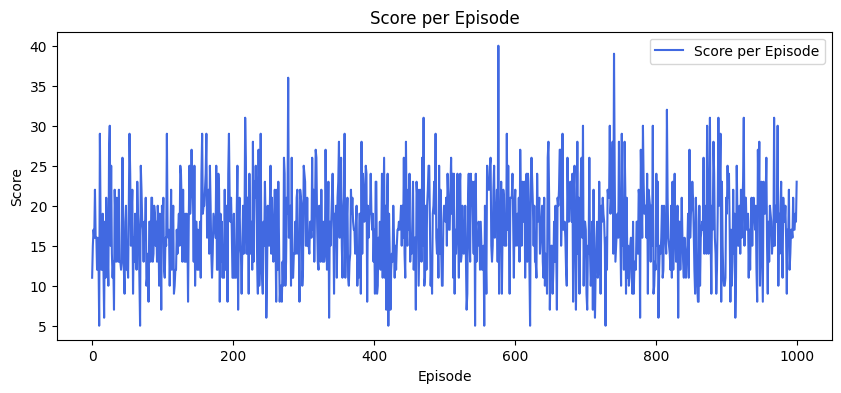

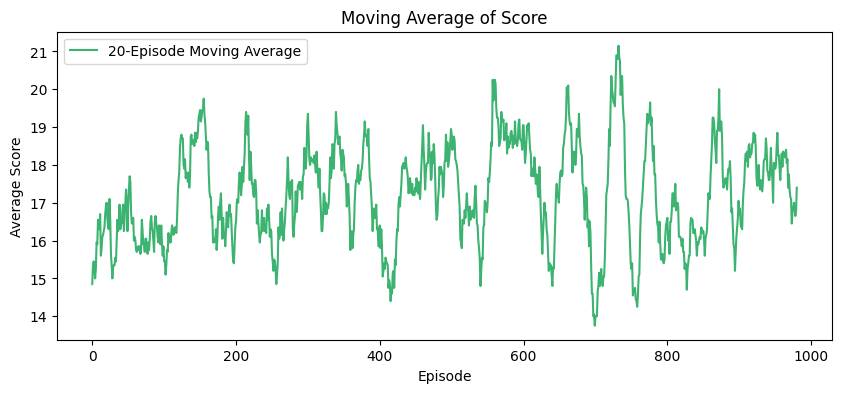

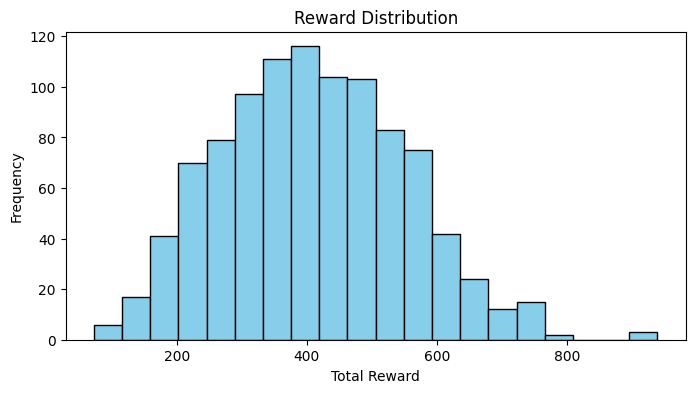

In [3]:
# ------------------------------------------------------------
# 4️⃣ Plot performance metrics
# ------------------------------------------------------------

# --- Score per episode ---
plt.figure(figsize=(10, 4))
plt.plot(scores, label='Score per Episode', color='royalblue')
plt.xlabel('Episode')
plt.ylabel('Score')
plt.title('Score per Episode')
plt.legend()
plt.show()

# --- Moving average of score ---
window = 20
moving_avg = np.convolve(scores, np.ones(window)/window, mode='valid')
plt.figure(figsize=(10, 4))
plt.plot(moving_avg, label=f'{window}-Episode Moving Average', color='mediumseagreen')
plt.xlabel('Episode')
plt.ylabel('Average Score')
plt.title('Moving Average of Score')
plt.legend()
plt.show()

# --- Reward distribution ---
plt.figure(figsize=(8, 4))
plt.hist(rewards, bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Total Reward')
plt.ylabel('Frequency')
plt.title('Reward Distribution')
plt.show()


## Action and Q-Value Analysis

In this section, we analyze **how the Deep SARSA agent makes decisions** during gameplay.

### What we examine:
1. **Action Selection Frequency** – how often the agent chose each action  
2. **Q-Value Distribution** – the value estimates for each action, reflecting confidence in decision-making  

Together, these visualizations help interpret the learned policy and the model’s behavioral tendencies.


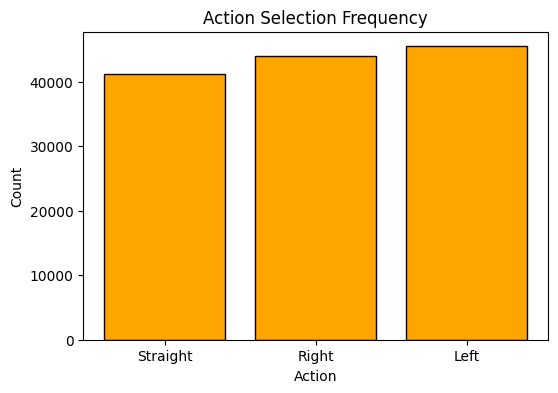

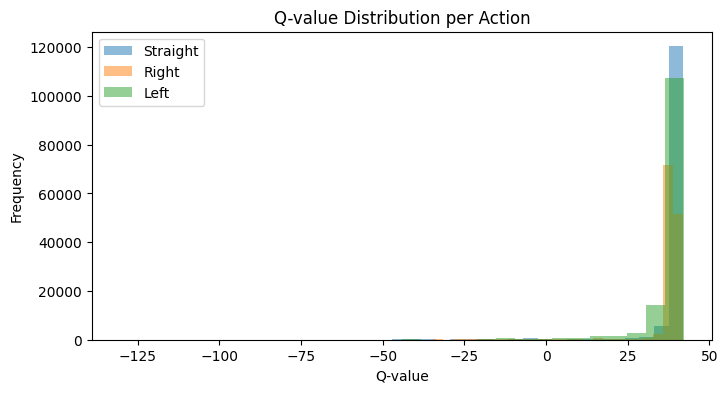

In [4]:
# ------------------------------------------------------------
# 5️⃣ Action and Q-value analysis
# ------------------------------------------------------------

# --- Action selection frequency ---
action_counts = Counter(actions_all)
actions = ['Straight', 'Right', 'Left']
counts = [action_counts.get(i, 0) for i in range(3)]

plt.figure(figsize=(6, 4))
plt.bar(actions, counts, color='orange', edgecolor='black')
plt.xlabel('Action')
plt.ylabel('Count')
plt.title('Action Selection Frequency')
plt.show()

# --- Q-value distribution per action ---
q_values_all = np.array(q_values_all)

plt.figure(figsize=(8, 4))
for i, label in enumerate(actions):
    plt.hist(q_values_all[:, i], bins=30, alpha=0.5, label=label)
plt.xlabel('Q-value')
plt.ylabel('Frequency')
plt.title('Q-value Distribution per Action')
plt.legend()
plt.show()
